In [2]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install seaborn
%pip install scikit-learn

  Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.5-cp313-cp313-win_amd64.whl (12.6 MB)
Note: you may need to restart the kernel to use updated packages.
  Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-2.2.3-cp313-cp313-win_amd64.whl (11.5 MB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)

   ---------------------------------------- 0/3 [pytz]
   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   --------------------------

Generating synthetic genomic data...
Generated data for 1000 individuals with 50 SNPs
Disease prevalence: 0.52

Calculating polygenic risk scores...

Visualizing results...


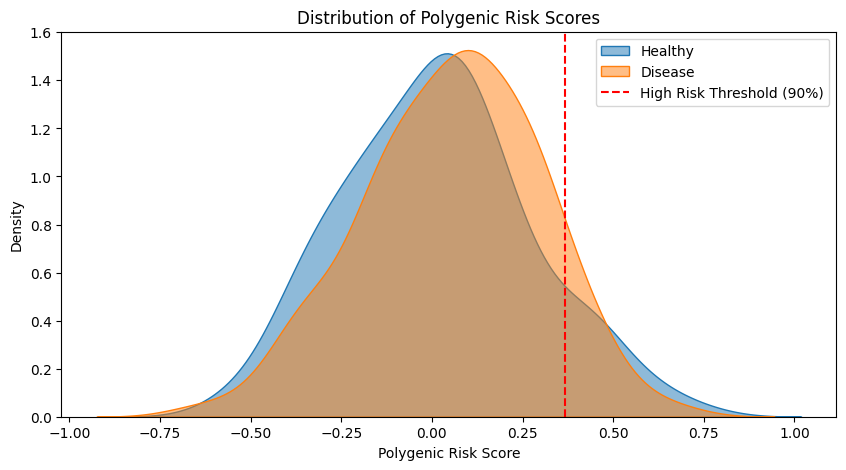

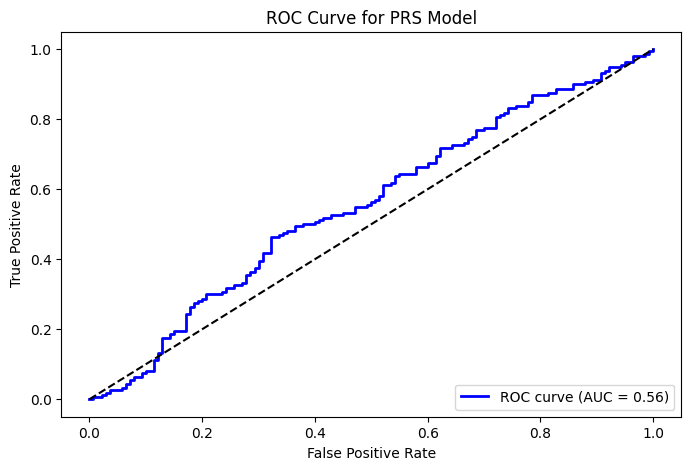


Demonstrating population bias...


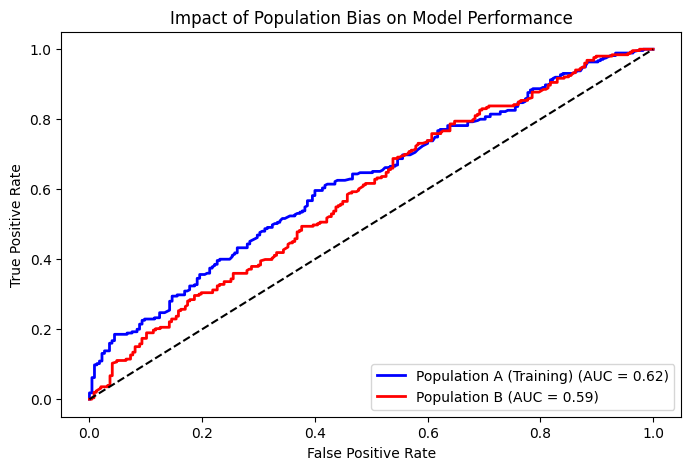


Demonstrating risk stratification...


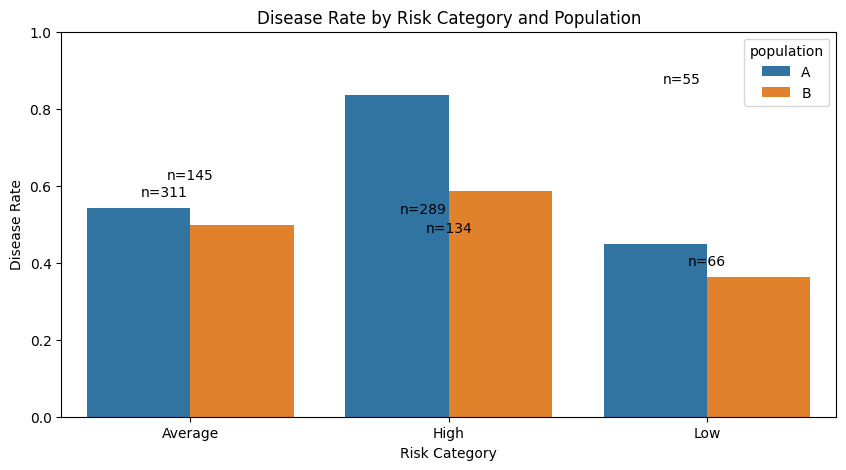

Demo complete!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc

# Set random seed for reproducibility
np.random.seed(42)

# PART 1: Generate Synthetic Genomic Data
print("Generating synthetic genomic data...")

# Number of individuals and SNPs
n_samples = 1000
n_snps = 50

# Generate SNP data (0, 1, or 2 copies of risk allele)
snp_data = np.random.randint(0, 3, size=(n_samples, n_snps))

# Generate effect sizes (most small, a few larger)
effect_sizes = np.random.normal(0, 0.05, n_snps)
effect_sizes[0:5] = np.random.normal(0, 0.5, 5)  # Make 5 SNPs more important

# Calculate true polygenic risk score
true_prs = np.dot(snp_data, effect_sizes)

# Generate disease status (0=healthy, 1=disease)
probability = 1 / (1 + np.exp(-(true_prs + np.random.normal(0, 1, n_samples))))
disease_status = np.random.binomial(1, probability)

# Create dataframe
columns = [f"SNP_{i}" for i in range(n_snps)]
df = pd.DataFrame(snp_data, columns=columns)
df["true_prs"] = true_prs
df["disease"] = disease_status

print(f"Generated data for {n_samples} individuals with {n_snps} SNPs")
print(f"Disease prevalence: {df['disease'].mean():.2f}")

# Display first few rows
print(df.head())

# PART 2: Basic Polygenic Risk Score Modeling
print("\nCalculating polygenic risk scores...")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(["true_prs", "disease"], axis=1),
    df["disease"],
    test_size=0.3,
    random_state=42
)

# Train a simple model to estimate effect sizes
model = LogisticRegression(penalty='l1', solver='liblinear', C=0.1)
model.fit(X_train, y_train)

# Get estimated effect sizes
estimated_effects = model.coef_[0]

# Calculate PRS for test set
estimated_prs = np.dot(X_test, estimated_effects)

# PART 3: Visualize Results
print("\nVisualizing results...")

# Create results dataframe
results = pd.DataFrame({
    'true_prs': df.loc[X_test.index, 'true_prs'],
    'estimated_prs': estimated_prs,
    'disease': y_test
})

# Plot PRS distribution by disease status
plt.figure(figsize=(10, 5))
sns.kdeplot(results[results.disease==0]['estimated_prs'],
            label='Healthy', fill=True, alpha=0.5)
sns.kdeplot(results[results.disease==1]['estimated_prs'],
            label='Disease', fill=True, alpha=0.5)
plt.axvline(results['estimated_prs'].quantile(0.9), color='red',
            linestyle='--', label='High Risk Threshold (90%)')
plt.title('Distribution of Polygenic Risk Scores')
plt.xlabel('Polygenic Risk Score')
plt.ylabel('Density')
plt.legend()
plt.show()

# Calculate ROC curve
pred_probs = 1 / (1 + np.exp(-estimated_prs))
fpr, tpr, _ = roc_curve(y_test, pred_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for PRS Model')
plt.legend(loc="lower right")
plt.show()

# PART 4: Population Bias Demonstration
print("\nDemonstrating population bias...")

# Generate data for two populations with different genetic structures
def generate_pop_data(n_samples, n_snps, allele_freq, effect_modifier, pop_name):
    # Generate SNP data with different allele frequencies
    snp_data = np.random.binomial(2, allele_freq, size=(n_samples, n_snps))

    # Modify effect sizes for this population
    pop_effects = effect_sizes * effect_modifier + np.random.normal(0, 0.05, n_snps)

    # Calculate risk scores and disease status
    prs = np.dot(snp_data, pop_effects)
    prob = 1 / (1 + np.exp(-(prs + np.random.normal(0, 1, n_samples))))
    disease = np.random.binomial(1, prob)

    # Create dataframe
    df = pd.DataFrame(snp_data, columns=columns)
    df["prs"] = prs
    df["disease"] = disease
    df["population"] = pop_name

    return df

# Generate data for two different populations
pop_A = generate_pop_data(500, n_snps, allele_freq=0.3, effect_modifier=1.0, pop_name="A")
pop_B = generate_pop_data(500, n_snps, allele_freq=0.5, effect_modifier=0.7, pop_name="B")

# Train model on population A only
X_A = pop_A.drop(["prs", "disease", "population"], axis=1)
y_A = pop_A["disease"]
model.fit(X_A, y_A)

# Test on both populations
X_B = pop_B.drop(["prs", "disease", "population"], axis=1)
y_B = pop_B["disease"]

# Calculate predictions for both populations
y_pred_A = model.predict_proba(X_A)[:, 1]
y_pred_B = model.predict_proba(X_B)[:, 1]

# Calculate ROC for population A (training population)
fpr_A, tpr_A, _ = roc_curve(y_A, y_pred_A)
roc_auc_A = auc(fpr_A, tpr_A)

# Calculate ROC for population B (different population)
fpr_B, tpr_B, _ = roc_curve(y_B, y_pred_B)
roc_auc_B = auc(fpr_B, tpr_B)

# Plot comparative ROC curves
plt.figure(figsize=(8, 5))
plt.plot(fpr_A, tpr_A, color='blue', lw=2,
         label=f'Population A (Training) (AUC = {roc_auc_A:.2f})')
plt.plot(fpr_B, tpr_B, color='red', lw=2,
         label=f'Population B (AUC = {roc_auc_B:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Impact of Population Bias on Model Performance')
plt.legend(loc="lower right")
plt.show()

# PART 5: Risk Stratification
print("\nDemonstrating risk stratification...")

# Combine populations
combined = pd.concat([pop_A, pop_B])

# Calculate predicted risk for everyone
X_combined = combined.drop(["prs", "disease", "population"], axis=1)
y_combined = combined["disease"]
pop_combined = combined["population"]

# Get predicted probabilities
risks = model.predict_proba(X_combined)[:, 1]

# Assign risk categories
def get_risk_category(risk):
    if risk < np.percentile(risks, 20):
        return "Low"
    elif risk > np.percentile(risks, 80):
        return "High"
    else:
        return "Average"

# Add risk categories
risk_categories = [get_risk_category(r) for r in risks]
risk_df = pd.DataFrame({
    'risk_score': risks,
    'disease': y_combined,
    'risk_category': risk_categories,
    'population': pop_combined
})

# Calculate disease rates by risk category and population
results = risk_df.groupby(['risk_category', 'population']).agg(
    disease_rate=('disease', 'mean'),
    count=('disease', 'count')
).reset_index()

# Plot disease rates by risk category and population
plt.figure(figsize=(10, 5))
sns.barplot(x='risk_category', y='disease_rate', hue='population', data=results)
plt.title('Disease Rate by Risk Category and Population')
plt.xlabel('Risk Category')
plt.ylabel('Disease Rate')
plt.ylim(0, 1)

# Add sample counts above bars
for i, row in enumerate(results.itertuples()):
    plt.text(i % 3 + (i//3)*0.1 - 0.1, row.disease_rate + 0.03,
             f'n={row.count}', ha='center')

plt.show()

print("Demo complete!")